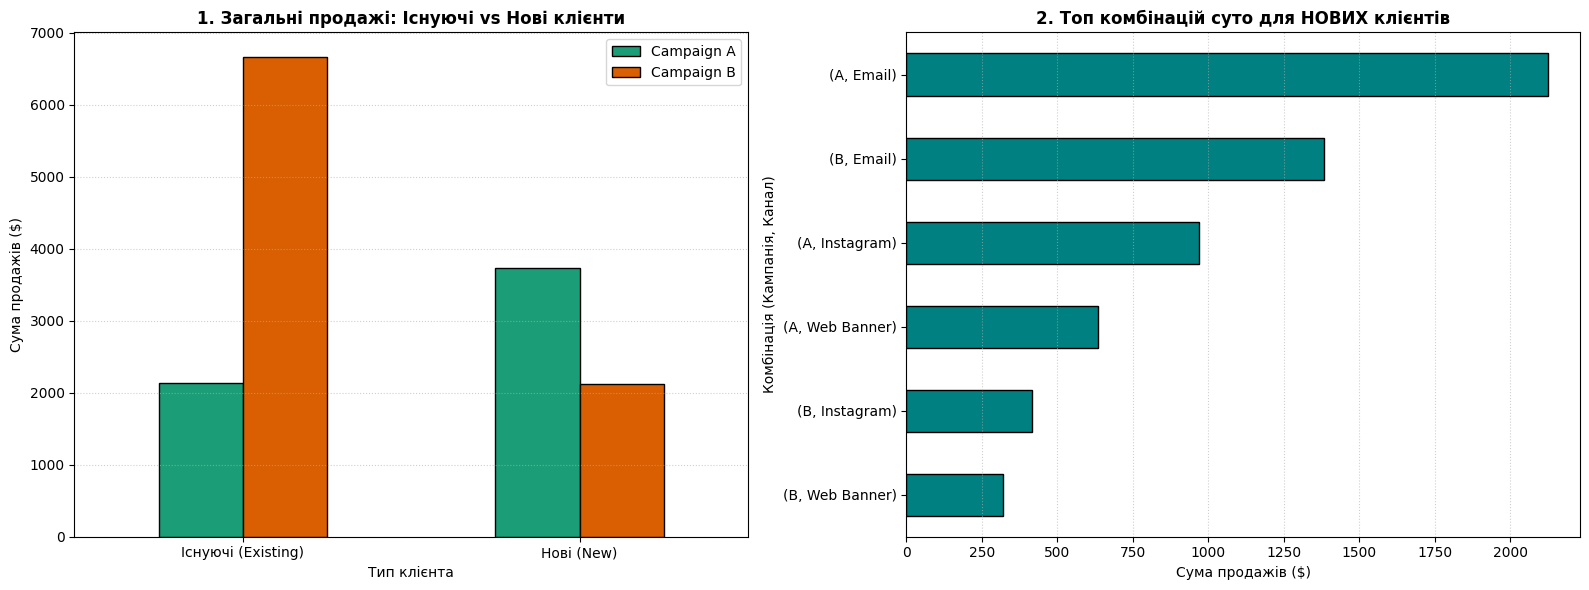

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


#КРОК 1: Завантаження та нормалізація даних

df_data = pd.read_excel('/content/Campaign_Data_Week1.xlsx', sheet_name='Raw_Data')

#очищення колонок
df_data.columns = df_data.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('($)', '', regex=False).str.replace('__', '_')


#КРОК 2: Агрегація та аналіз (Базові таблиці та Маски)
#Загальні продажі
total_sales_to_channel = df_data.groupby('channel')['sales_'].sum()
total_sales_to_campaign = df_data.groupby('campaign_type')['sales_'].sum()

#Маска для нових клієнтів
new_mask = df_data['customer_type'].str.contains('New', case=False, na=False)
df_new = df_data[new_mask]

#Зведені дані для побудови графіків
pivotdata = df_new.groupby(['channel', 'campaign_type'])['sales_'].sum()
sales_by_cust = df_data.groupby(['customer_type', 'campaign_type'])['sales_'].sum().unstack()
pivot_new_combo = df_new.groupby(['campaign_type', 'channel'])['sales_'].sum().sort_values(ascending=True)


#КРОК 3: Візуалізація результатів (Створення комбо-графіка)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

#ГРАФІК 1: Існуючі vs Нові клієнти (використовуємо sales_by_cust)
sales_by_cust.plot(kind='bar', ax=ax1, color=['#1b9e77', '#d95f02'], edgecolor='black')
ax1.set_title('1. Загальні продажі: Існуючі vs Нові клієнти', fontsize=12, fontweight='bold')
ax1.set_xlabel('Тип клієнта', fontsize=10)
ax1.set_ylabel('Сума продажів ($)', fontsize=10)
ax1.grid(axis='y', linestyle=':', alpha=0.6)
ax1.set_xticklabels(['Існуючі (Existing)', 'Нові (New)'], rotation=0)
ax1.legend(['Campaign A', 'Campaign B'])

# ГРАФІК 2: Топ комбінацій СУТО для Нових клієнтів
pivot_new_combo.plot(kind='barh', ax=ax2, color='teal', edgecolor='black')
ax2.set_title('2. Топ комбінацій суто для НОВИХ клієнтів', fontsize=12, fontweight='bold')
ax2.set_xlabel('Сума продажів ($)', fontsize=10)
ax2.set_ylabel('Комбінація (Кампанія, Канал)', fontsize=10)
ax2.grid(axis='x', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('bcg_x_insights.png', dpi=300)
plt.show()